Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
File read sucecs fully
Model training done 

Model intercpeiton 1322.1455297711655 

y_pridect valye is [436881.66368862 509941.46673973 202655.11222615 ... 579335.54522602
 394363.09007686 325027.82720128]
Average MAE is 47378.40821378903
Average MSE is 3762154089.911888
Average rmse is 61336.40101857859
Average r2 is 0.9064084087254987

Model Evaluation:
MAE  : 47378.4082
MSE  : 3762154089.9119
RMSE : 61336.4010
R2   : 0.9064

Actual vs Predicted:
      Actual Price  Predicted Price
0           403938    436881.663689
1           395652    509941.466740
2           222505    202655.112226
3           475402    461522.444458
4           121542    162190.930727
...            ...              ...
2995        617125    650191.974557
2996        190980    201314.277763
2997        567841    579335.545226
2998        340748    394363.090077
2999        332688   

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


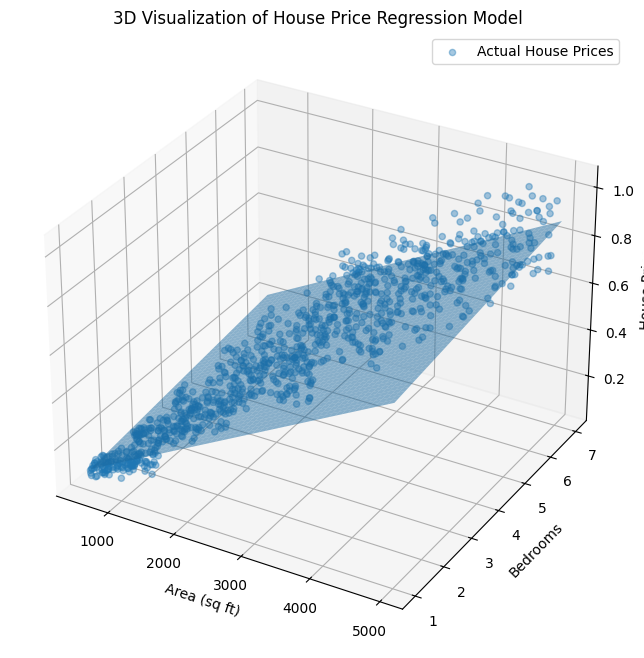

In [16]:
from google.colab import drive
from pathlib import  Path
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as pt 
from mpl_toolkits.mplot3d import Axes3D


drive.mount('/content/drive')
base_url = Path('/content/drive/MyDrive/GenerativeAI')
file_url = base_url / 'house_price_training_data_10000.xlsx'

df = pd.read_excel(file_url)

print(f"File read sucecs fully")

x = df[["Area_sq_ft","Bedrooms"]]
y = df["House_Price"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=.3, random_state=42)

model = LinearRegression()
model.fit(x_train, y_train)

print(f"Model training done \n")

print(f"Model intercpeiton {model.intercept_} \n")



#predict on test data
y_predict = model.predict(x_test)
print(f"y_pridect valye is {y_predict}")
#evaluate the model, Calculate the avarage absolute difference between actual and predicted values
averageMAE = mean_absolute_error(y_test, y_predict)

print(f"Average MAE is {averageMAE}")
#calculate MSE, Penalizes larger errors more strongly
mse = mean_squared_error(y_test, y_predict)
print(f"Average MSE is {mse}")

#Caluclate RMSE, square root of MSE, Easier to understand,because it is in same unit as traget
rmse = np.sqrt(mse)

print(f"Average rmse is {rmse}")

#calcutae R2 store, Shows how well the model explains the variation in productivity

r2 = r2_score(y_test, y_predict)
print(f"Average r2 is {r2}")
print("\nModel Evaluation:")
print(f"MAE  : {averageMAE:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R2   : {r2:.4f}")

results = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_predict
})
print("\nActual vs Predicted:")
print(results)


plot_df = df.sample(frac=0.1, random_state=42)

area_data = plot_df["Area_sq_ft"]
bedroom = plot_df["Bedrooms"]
price = plot_df["House_Price"]

area_range = np.linspace(area_data.min(), area_data.max(), 50)
bedroom_range = np.linspace(bedroom.min(), bedroom.max(), 50)
area_grid, bedroom_grid = np.meshgrid(area_range, bedroom_range)

grid_input = np.c_[area_grid.ravel(), bedroom_grid.ravel()]

predicted_price_grid = model.predict(grid_input)
price_grid = predicted_price_grid.reshape(area_grid.shape)


fig = pt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot for actual data
ax.scatter(
    area_data,
    bedroom,
    price,
    alpha=0.4,
    label="Actual House Prices"
)

# Surface plot for regression plane
ax.plot_surface(
    area_grid,
    bedroom_grid,
    price_grid,
    alpha=0.5
)

# Labels and title
ax.set_xlabel("Area (sq ft)")
ax.set_ylabel("Bedrooms")
ax.set_zlabel("House Price")
ax.set_title("3D Visualization of House Price Regression Model")

pt.legend()
pt.show()